<h1 style="color:red;">Numerical Simulation Laboratory - Exercise 4.2</h1>

The aim of this exercise is to study the emergence of the Maxwell-Boltzmann velocity distribution from a highly ordered, low-entropy initial state. The system is initialized with particles arranged in a compact FCC configuration and with a highly constrained velocity distribution. In particular, the initial velocity distribution is chosen as

$$
p_\delta(v^*,T^*)=\delta\left(v^*-v_{T^*}\right),
$$

where the characteristic velocity is related to the initial temperature through

$$
v_{T^*}=\sqrt{3T^*}.
$$

By evolving the system through Molecular Dynamics while conserving the total energy, we observe how both the spatial configuration and the velocity distribution progressively evolve towards equilibrium. Since the kinetic energy and temperature are not conserved quantities, the system reaches an effective equilibrium temperature $T^*_{\mathrm{eff}}$, which is then used to compare the final velocity distribution with the Maxwell-Boltzmann prediction.

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

In [2]:
data = np.loadtxt("nsl_simulator/NSL_SIMULATOR/OUTPUT/pofv.dat", skiprows=1)
initial_data = np.loadtxt("nsl_simulator/NSL_SIMULATOR/OUTPUT/initial_pofv.dat", skiprows=1)

In [3]:
block = data[:, 0]
velocity = data[:, 1]
ave_pofv = data[:, 2]
ave_prog = data[:, 3]
error = data[:, 4]

In [4]:
initial_pofv=initial_data[:, 0]
initial_velocity=initial_data[:, 1]

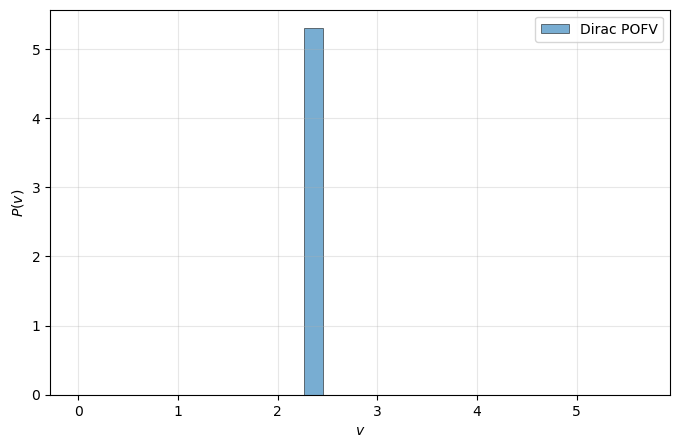

In [5]:
dv = initial_pofv[1] - initial_pofv[0]

plt.figure(figsize=(8, 5))

plt.bar(initial_pofv, initial_velocity,
        width=dv, alpha=0.6, edgecolor = "black",
        linewidth = 0.6, label="Dirac POFV")

plt.xlabel(r"$v$")
plt.ylabel(r"$P(v)$")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

**Figure 1**. The initial velocity distribution is obtained using the same parameters adopted in Exercise 4.1. A new function, `write_initial_pofv`, was added to `System.cpp` to record the velocity distribution before starting the Molecular Dynamics evolution. As expected from the chosen initial condition, the histogram consists of a single populated bin, corresponding to the characteristic initial velocity

$$
v_{T^*}=\sqrt{3T^*}.
$$

This confirms that the initial velocity distribution is strongly constrained and approximates the idealized delta distribution used to initialize the system.

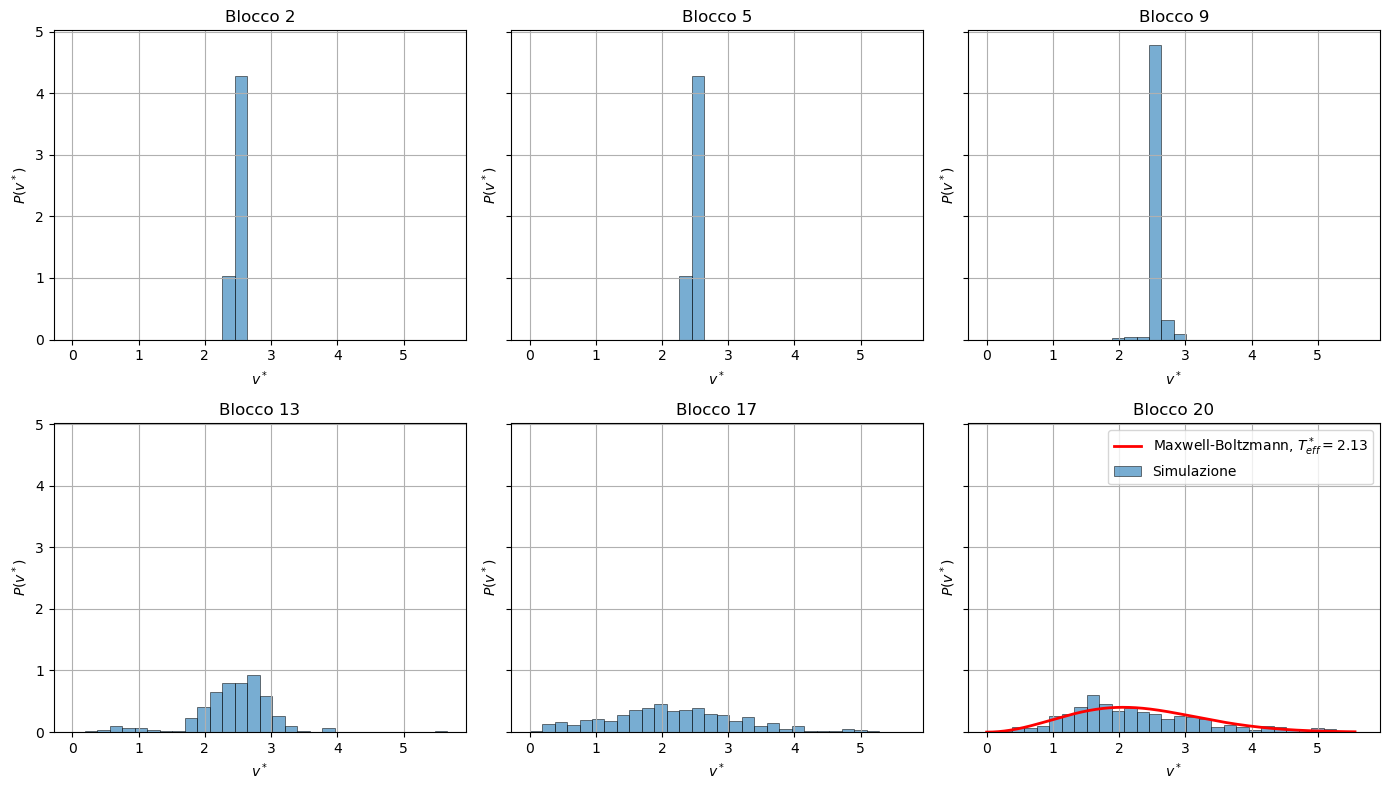

In [7]:
blocks_to_plot = [2, 5, 9, 13, 17, 20]
dv = velocity[1] - velocity[0]

# Temperatura effettiva dopo l'equilibrio
T_eff = 2.12584

# Maxwell-Boltzmann teorica
v_theory = np.linspace(0, np.max(velocity), 500)

pofv_theory = (
    4 / np.sqrt(np.pi)
    * (1 / (2 * T_eff))**(3/2)
    * v_theory**2
    * np.exp(-v_theory**2 / (2 * T_eff))
)

# Figura 2 x 3
fig, axs = plt.subplots(2, 3, figsize=(14, 8), sharey=True)

for ax, b in zip(axs.flat, blocks_to_plot):

    mask = block == b

    v = velocity[mask]
    p = ave_pofv[mask]
    err = error[mask]

    # Distribuzione
    ax.bar(
        v,
        p,
        width=dv,
        alpha=0.6,
        edgecolor = "black",
        linewidth = 0.6,
        label="Simulazione"
    )

    # Maxwell-Boltzmann solo nell'ultimo blocco
    if b == 20:
        ax.plot(
            v_theory,
            pofv_theory,
            color = "red",
            linewidth=2,
            label=rf"Maxwell-Boltzmann, $T^*_{{eff}}={T_eff:.2f}$"
        )

    ax.set_title(f"Blocco {b}")
    ax.set_xlabel(r"$v^*$")
    ax.set_ylabel(r"$P(v^*)$")
    ax.grid()

    if b == 20:
        ax.legend()

plt.tight_layout()
plt.show()

**Figure 2.** The figure shows the evolution of the velocity distribution obtained from the Molecular Dynamics simulation for blocks $2$, $5$, $9$, $13$, $17$, and $20$. Starting from the highly constrained initial condition, the distribution progressively broadens and approaches the expected Maxwell-Boltzmann shape as the system evolves towards equilibrium. In the final block, the simulated distribution is compared with the theoretical Maxwell-Boltzmann distribution evaluated at the effective equilibrium temperature $T^*_{\mathrm{eff}}=2.12584$. The good agreement between the final distribution and the theoretical prediction indicates that the system has reached a state close to thermodynamic equilibrium.

### Conclusion

The evolution of the system provides an example of the connection between entropy and irreversibility. The initial configuration is highly ordered, both in position and in velocity: the particles are arranged in a compact FCC structure and all have the same velocity magnitude. As the Molecular Dynamics simulation proceeds, this ordered state progressively evolves towards a more homogeneous spatial configuration, while the initially constrained velocity distribution broadens and approaches the Maxwell-Boltzmann distribution. The system therefore moves from a highly ordered and statistically unlikely state towards a more probable equilibrium state, corresponding to an increase in entropy.

At the microscopic level, however, the equations governing the dynamics are time reversible. In principle, if all particle velocities were exactly reversed at a given instant, the system should retrace its previous trajectory and eventually return to its initial configuration. This apparent contradiction between microscopic reversibility and macroscopic irreversibility is related to the enormous sensitivity of many-particle systems to their initial conditions.

In a numerical simulation, an exact reversal of the trajectory is practically impossible. Even extremely small numerical errors, such as round-off errors and errors introduced by the finite integration time step, are amplified by the chaotic dynamics of the system. Consequently, after reversing the velocities, the new trajectory rapidly diverges from the original one. The system therefore does not return to the initial low-entropy configuration, but instead evolves towards equilibrium again.

This behaviour shows how a system governed by time-reversible microscopic equations can nevertheless display irreversible macroscopic behaviour. The Maxwell-Boltzmann distribution acts as the equilibrium state towards which the system relaxes, while the return to the original highly ordered state is statistically extremely unlikely for a macroscopic system. The observed evolution therefore provides a numerical illustration of the second law of thermodynamics and of the distinction between microscopic reversibility and macroscopic irreversibility.